In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary

_ = torch.manual_seed(42)

_ = np.random.seed(0)

# Define Lotka Volterra Simulator
def lotka_volterra(y, alpha, beta, delta, gamma):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = delta * prey * predator - gamma * predator
    return np.asarray([dprey_dt, dpredator_dt])

def simulate_total(parameters, t_span):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]

    y0 = np.asarray([40.0, 9.0])  # Initial populations
    #t_span = 400  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(2*t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

def choose_splitter(nparray, split_method):
    if split_method == 'even_odd':
        return split_by_even_odd(nparray)
    elif split_method == 'first_second':
        return split_in_two(nparray)
    else:
        raise ValueError(f"Unknown split type: {split_method}")
    

# split into two halves
def split_in_two(nparray):
    n = len(nparray)
    mid = n//2
    res1 = nparray[:mid]
    res2 = nparray[mid:]
    return res1, res2

# split by even/odd indices
def split_by_even_odd(nparray):
    even = nparray[::2]
    odd = nparray[1::2]
    m = min(len(even), len(odd))
    even, odd = even[:m], odd[:m]
    return even, odd


# Define how populations evolve
def simulate(parameters, observation, t_span):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]


    y0 = np.asarray([observation[0, 0], observation[0, 1]])  # Initial populations
    #t_span = 200  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

# Extract observed data
def extract_data(url):
    df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)
    df.index.name = 'Year'
    df.columns = ['Hare', 'Lynx']
    time_vec = df.index.values
    observation = df[['Hare', 'Lynx']].values
    print(observation.shape)
    n_obs = observation.shape[0]
    sigma_hare = 0.2 * np.std(observation[:, 0])   # 20% of hare std
    sigma_lynx = 0.2 * np.std(observation[:, 1])   # 20% of lynx std
    return time_vec, observation, n_obs, sigma_hare, sigma_lynx

# Plot figures for observed lynx hare populations
def plot_observed_data(time_vec, observation):
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    _ = ax.plot(time_vec, observation)
    _ = ax.legend(["Prey", "Predator"])
    _ = ax.set_xlabel("Time")
    _ = ax.set_ylabel("Population")

# Use mean and max as summary statistics
def summarize_simulation(simulation_result):

    prey_population = simulation_result[:, 0]
    predator_population = simulation_result[:, 1]
    
    summary = [
        np.max(prey_population).item(),
        np.max(predator_population).item(),
        np.mean(prey_population).item(),
        np.mean(predator_population).item()
    ]
    return np.asarray(summary)

# pick out n_obs points to ensure arrays are same size
def downsample_to_n_obs(sim_result, n_obs):
    # pick out n_obs points to ensure arrays are same size
    T = sim_result.shape[0]
    idx = np.linspace(0, T - 1, n_obs).astype(int)
    return sim_result[idx]

# returns data that is same size as observed, adding no noise
def simulate_match_data(parameters, n_obs,observation, t_span):
    # returns data that is same size as observed, adding no noise
    full_traj = simulate(parameters,observation,t_span)            # (2000, 2)
    return downsample_to_n_obs(full_traj, n_obs)  # (n_obs, 2)

# Returns simulations with gaussian noise added
def simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    latent = simulate_match_data(parameters, n_obs,observation, t_span)
    noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=latent.shape
    )
    # Column 0 ~ N(0, sigma_hare^2), column 1 ~ N(0, sigma_lynx^2)
    noisy = latent + noise
    return noisy

# Return simulations with poissoin noise added
def simulate_poisson(parameters, n_obs, observation, t_span):
    latent = simulate_match_data(parameters, n_obs, observation, t_span)
    lam = np.clip(latent, 1e-6, None)
    noisy_counts = np.random.poisson(lam)
    return noisy_counts

# Wrapper function to choose noise
def simulator_distribution(distn, parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    if distn == 'none':
        result = simulate_match_data(parameters, n_obs, observation,t_span)
    elif distn == 'gaussian':
        result = simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span)
    elif distn == 'poisson':
        result = simulate_poisson(parameters, n_obs, observation, t_span)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    return result

# Define a uniform prior
def define_uniform_prior():
    lower_bound = torch.as_tensor([0.05, 0.01, 0.005, 0.005])
    upper_bound = torch.as_tensor([0.15, 0.03, 0.03, 0.15])
    prior = BoxUniform(low=lower_bound, high=upper_bound)
    return prior

# Define a log-normal prior
def define_logn_prior():
    log_means = torch.log(torch.tensor([
        0.1,   # alpha - 1.6
        0.02,   # beta - 3.2
        0.015,  # delta - 0.6
        0.08    # gamma - 0.56
    ]))

    log_stds = torch.tensor([0.3, 0.3, 0.3, 0.3])

    # Build prior
    base_dist = LogNormal(loc=log_means, scale=log_stds)
    prior_lognormal = Independent(base_dist, 1)
    return prior_lognormal


# Wrapper Function to choose prior distn
def choose_prior_and_generate_theta(distn):
    if distn == 'uniform':
        prior = define_uniform_prior()
    elif distn == 'logn':
        prior = define_logn_prior()
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    
    theta = prior.sample((10_000,))
    return prior, theta

# simulator function
def parallel_simulate(theta,distn, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    # Our simulator uses numpy, but prior samples are in PyTorch.
    theta_np = theta.numpy()

    num_workers = 8
    simulation_outputs = Parallel(n_jobs=num_workers)(
        delayed(simulator_distribution)(distn,batch,n_obs, sigma_hare, sigma_lynx, observation, t_span)
        for batch in theta_np
    )
    return np.asarray(simulation_outputs)

# generate simulations
def generate_x(theta,distn, n_obs,sigma_hare,sigma_lynx, observation, t_span):
    simulation_outputs = parallel_simulate(theta,distn, n_obs,sigma_hare, sigma_lynx, observation, t_span)
    x = torch.as_tensor(np.asarray([summarize_simulation(sim) for sim in simulation_outputs]), dtype=torch.float32)
    return x

# plot to check simulated data covers observed data
def plot_checker(x, x_obs):
        _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=[[0, 200], [0, 150], [0, 25], [0, 50]],
        figsize=(4, 4),
    )


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:

# Generate net, stopping after max epochs, choosing or not choosing to 
def train_net_generate_samples(x,theta,x_obs, prior, verbose, max_epoch,true_val):
    
    inference = NPE(prior= prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=max_epoch, stop_after_epochs=30)
    posterior_direct = inference.build_posterior(density_estimator=posterior_net,sample_with="direct")
    posterior_mcmc = inference.build_posterior(density_estimator=posterior_net,sample_with="mcmc")
    samples = posterior_mcmc.sample((1_000,), x=x_obs)

    if verbose == True:
        _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        _ = pairplot(
            samples,
            points = true_val[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )
        
    return samples, posterior_mcmc, posterior_direct, inference

In [3]:
'''

results = {
        "samples1": samples1,          # posterior samples (1000, 4)
        "samples2": samples2,          # posterior samples (1000, 4)
        "posterior1_mcmc": posterior1_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior1_direct": posterior1_direct,   # sbi posterior object (if you want to reuse it)
        "posterior2_mcmc": posterior2_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior2_direct": posterior2_direct,   # sbi posterior object (if you want to reuse it)
        "inference1": inference1,      # NPE object
        "inference2": inference2,      # NPE object
        "prior1": prior1,
        "prior2": prior2,
        "theta1": theta1,              # simulated θ used for training (10000, 4)
        "theta2": theta2,              # simulated θ used for training (10000, 4)
        "x1": x1,                      # simulated summaries (10000, 4)
        "x2": x2,                      # simulated summaries (10000, 4)
        "x_obs1": x_obs1,              # observed summary (4,)
        "x_obs2": x_obs2,              # observed summary (4,)
        "time_vec1": time1,        # years
        "time_vec2": time2,        # years
        "obs1": obs1,  # raw data (n_obs, 2)
        "obs2": obs2,  # raw data (n_obs, 2)
        "prior_name": prior_name,    # 'uniform' or 'logn'
        "noise1": noise1,        # 'none' / 'gaussian' / 'poisson'
        "noise2": noise2,        # 'none' / 'gaussian' / 'poisson'
        "n_obs1": n_obs1,
        "n_obs2": n_obs2,
        "sigma_hare1": sigma_hare1,
        "sigma_lynx1": sigma_lynx1,
        "sigma_hare2": sigma_hare2,
        "sigma_lynx2": sigma_lynx2,
        "split_type": split_type,
        "t_span": t_span
    }

fname = f"CALIBRATION TESTER_split_{split_type}_results_{prior_name}_{noise1}.pt"
torch.save(results, fname)

'''

'\n\nresults = {\n        "samples1": samples1,          # posterior samples (1000, 4)\n        "samples2": samples2,          # posterior samples (1000, 4)\n        "posterior1_mcmc": posterior1_mcmc,   # sbi posterior object (if you want to reuse it)\n        "posterior1_direct": posterior1_direct,   # sbi posterior object (if you want to reuse it)\n        "posterior2_mcmc": posterior2_mcmc,   # sbi posterior object (if you want to reuse it)\n        "posterior2_direct": posterior2_direct,   # sbi posterior object (if you want to reuse it)\n        "inference1": inference1,      # NPE object\n        "inference2": inference2,      # NPE object\n        "prior1": prior1,\n        "prior2": prior2,\n        "theta1": theta1,              # simulated θ used for training (10000, 4)\n        "theta2": theta2,              # simulated θ used for training (10000, 4)\n        "x1": x1,                      # simulated summaries (10000, 4)\n        "x2": x2,                      # simulated 

In [4]:
def load_results_file(file_name):
    res = torch.load(file_name)
    return res

def extract_results(res):
    """
    Given a loaded results dict, return a tuple in a fixed order.
    This is explicit and avoids surprises.
    """
    keys = [
        "samples1", "samples2",
        "posterior1_mcmc", "posterior1_direct",
        "posterior2_mcmc", "posterior2_direct",
        "inference1", "inference2",
        "prior1", "prior2",
        "theta1", "theta2",
        "x1", "x2",
        "x_obs1", "x_obs2",
        "time_vec1", "time_vec2",
        "obs1", "obs2",
        "prior_name",
        "noise1", "noise2",
        "n_obs1", "n_obs2",
        "sigma_hare1", "sigma_lynx1",
        "sigma_hare2", "sigma_lynx2",
        "split_type"
    ]

    # update to include t_span when we retrain models

    missing = [k for k in keys if k not in res]
    if missing:
        raise KeyError(f"Missing keys in results dict: {missing}")

    return tuple(res[k] for k in keys)


In [5]:
fname1 = "CALIBRATION TESTER_split_even_odd_results_uniform_poisson.pt"
fname2 = "CALIBRATION TESTER_split_first_second_results_uniform_poisson.pt"

res = load_results_file(fname2)
# update to include t_span when we retrain models
(samples1, samples2,
 posterior1_mcmc, posterior1_direct,
 posterior2_mcmc, posterior2_direct,
 inference1, inference2,
 prior1, prior2,
 theta1, theta2,
 x1, x2,
 x_obs1, x_obs2,
 time1, time2,
 obs1, obs2,
 prior_name,
 noise1, noise2,
 n_obs1, n_obs2,
 sigma_hare1, sigma_lynx1,
 sigma_hare2, sigma_lynx2,
 split_type) = extract_results(res)

C:\Users\vasir\AppData\Local\Temp\ipykernel_4088\505596787.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res = torch.load(file_name)


In [6]:
t_span = 200

In [7]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        z = log_post1 - log_post2
        mean = z.mean().item()
        std_dev = z.std(unbiased = True).item()
        error = std_dev/np.sqrt(n_theta)

        return mean, std_dev, error

def calibrate_null_dkl(null_posterior, prior, N, n_theta, distn, n_obs, sigma_hare, sigma_lynx, observation, split_type, t_span):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        
        #print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        #traj_i = simulate_total(theta_i)
        traj_i = simulator_distribution(distn, theta_i, n_obs, sigma_hare, sigma_lynx, observation, 2*t_span)
        obs1_i, obs2_i = choose_splitter(traj_i,split_type)

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) #obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    #plot histogram
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Null calibration of D_KL (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


In [8]:

dkl_obs, std_obs, error_obs = calc_dkl(posterior1_direct, posterior2_direct, x_obs1, x_obs2, n_theta = 500)


dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, prior1,100,500, noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1, split_type, t_span)
print("DKL observed:", dkl_obs)        



c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


0/100


                        constant for `log_prob()`. However, only
                        0.000% posterior samples are within the
                        prior support (for condition 0). It may take a long time
                        to collect the remaining 10000 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.


KeyboardInterrupt: 

0/200
20/200
40/200
60/200
80/200
100/200
120/200
140/200
160/200
180/200


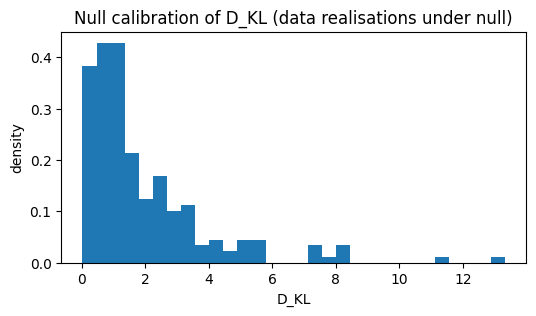

Null 95 percent critical value: 5.604434442520138
DKL observed: 16.764270782470703


In [ ]:

dkl_obs_2, std_obs_2, error_obs_2 = calc_dkl(posterior1_direct, posterior2_direct, x_obs1, x_obs2, n_theta = 2500)


dkls_2, crit_val_95_2 = calibrate_null_dkl(posterior1_direct, prior1,200,2500, noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1, split_type, t_span)
print("DKL observed:", dkl_obs_2)    

In [ ]:
#loop through N vals to see error as fn of n
N_theta_vals = [100,500,1000,5000,10000]

# empty array to store values
mean_vals=[0]*len(N_theta_vals)
std_dev_vals = [0]*len(N_theta_vals)
error_vals = [0]*len(N_theta_vals)

# generate some random test data, following same process:
def generate_loop_data(prior,distn, n_obs, sigma_hare, sigma_lynx, observation, split_type, t_span):
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        #traj_i = simulate_total(theta_i)
        traj_i = simulator_distribution(distn, theta_i, n_obs, sigma_hare, sigma_lynx, observation, 2*t_span)
        obs1_i, obs2_i = choose_splitter(traj_i,split_type)

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) #obtaining summary statistics of data
        return x1_i, x2_i

x1_loop, x2_loop = generate_loop_data(prior1, noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1, split_type, t_span)

for i in range(len(N_theta_vals)):
        n_theta = N_theta_vals[i]
        mean_vals[i], std_dev_vals[i], error_vals[i] = calc_dkl(posterior1_direct, posterior1_direct, x1_loop, x2_loop, n_theta = n_theta)
        print(i)



0
1
2
3
4


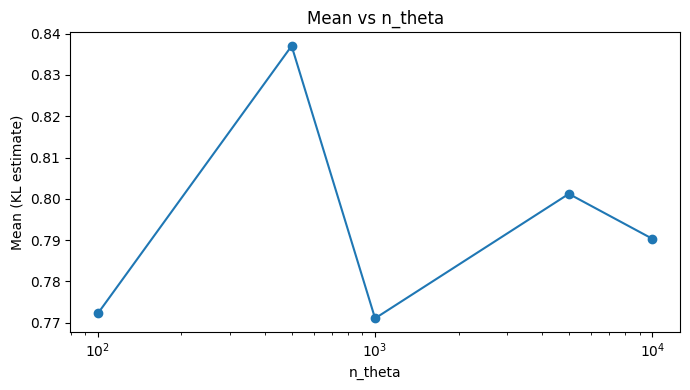

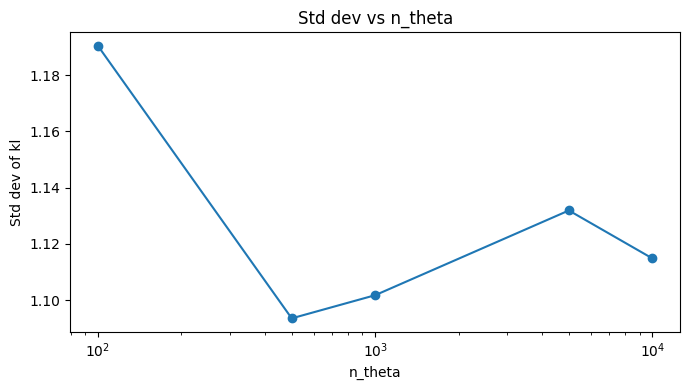

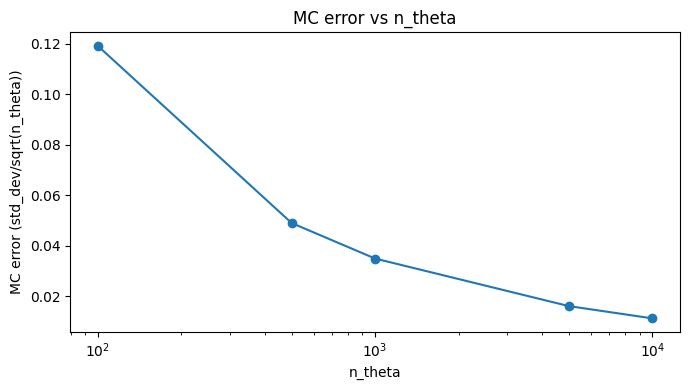

In [ ]:

N_theta_vals = np.array(N_theta_vals, dtype=float)
mean_vals = np.array(mean_vals, dtype=float)
std_dev_vals = np.array(std_dev_vals, dtype=float)
error_vals = np.array(error_vals, dtype=float)

# Plot mean
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, mean_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Mean (KL estimate)")
plt.title("Mean vs n_theta")
plt.tight_layout()
plt.show()

# 2) Std dev vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, std_dev_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Std dev of kl")
plt.title("Std dev vs n_theta")
plt.tight_layout()
plt.show()

# 3) Error vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, error_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("MC error (std_dev/sqrt(n_theta))")
plt.title("MC error vs n_theta")
plt.tight_layout()
plt.show()









In [ ]:
def calibrate_null_dkl_and_perturbed(null_posterior, prior, N, n_theta, distn, n_obs, sigma_hare, sigma_lynx, observation, split_type, t_span):

    dkls = np.zeros(N) # to store dkls
    dkls_perturbed  = np.zeros(N)
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        #traj_i = simulate_total(theta_i)
        traj_i = simulator_distribution(distn, theta_i, n_obs, sigma_hare, sigma_lynx, observation, 2*t_span)
        obs1_i, obs2_i = choose_splitter(traj_i,split_type)

        #create a perturbted obs1, with some small systematic added

        #### Try more perturbation ideas
        obs1_i_perturbed = obs1_i.copy().astype(float)
        obs1_i_perturbed[:, 1] *= 1.03 # contextually we scale up the population of lynx and down for hare
        obs1_i_perturbed[:, 0] *= 1
        
        x1_i_perturbed = summarize_simulation(obs1_i_perturbed)

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) #obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

        dkls_perturbed[i], std_dev2, error2 = calc_dkl(null_posterior, null_posterior, x1_i_perturbed, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    
    #plot histograms
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Null calibration of D_KL (data realisations under null)")
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(dkls_perturbed, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Perturbed calibration of D_KL (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)
    print("Perturbed 95 percent critical value:", crit_val_95_perturbed)

    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed

In [ ]:
dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed = calibrate_null_dkl_and_perturbed(posterior1_direct, prior1,100,500, noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1, split_type, t_span)

0/100
20/100
